# Эксперимент 13: Масштабирование разметки — 200 изображений на класс + синтетика

**Ключевые изменения:**
1. Отбираем **по 200 изображений на каждый класс** дефектов (KMeans по эмбеддингам DINOv2) → до ~800 реальных изображений
2. Добавляем синтетику copy-paste для классов 1 и 2 (как в Эксп.10), но теперь источниковый пул богаче

| Параметр | Эксп.10 | Эксп.12 | **Эксп.13** |
|---|---|---|---|
| Backbone | Разморожен (бл.8–11) | Разморожен (бл.8–11) | **Разморожен (бл.8–11)** |
| Декодер | DPT (4 слоя, 2.8М) | DPT (4 слоя, 2.8М) | **DPT (4 слоя, 2.8М)** |
| JointTransform | ✓ | ✓ | **✓** |
| Синтетика copy-paste | ✓ кл.1+2 (433) | ✓ кл.1+2 (433) | **✓ кл.1+2** |
| Реальных изображений | 200 | 200 | **≤778 (200/класс)** |

**Гипотеза:** Более широкий пул реальных изображений (200/класс) даёт синтетике разнообразные источники дефектов, что должно улучшить качество по сравнению с Эксп.10/12.

## 1. Импорты и конфигурация

In [1]:
import os, random, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from tqdm import tqdm
from collections import Counter
from scipy.ndimage import gaussian_filter
import sys

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchmetrics import JaccardIndex
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

print(f'Python: {sys.version}')
print(f'PyTorch: {torch.__version__}')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Устройство: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} Гб')

DATA_DIR      = 'C:/Users/ADMIN/Desktop/magistr/VKR/steel_defect/'
TRAIN_CSV     = os.path.join(DATA_DIR, 'train.csv')
TRAIN_IMG_DIR = os.path.join(DATA_DIR, 'train_images/')
save_dir      = 'C:/Users/ADMIN/Desktop/magistr/VKR/dino_heads'
os.makedirs(save_dir, exist_ok=True)

# ── Размеры ────────────────────────────────────────────────────────────
IMG_H       = 224
IMG_W       = 1400
PATCH_SIZE  = 14
PATCH_H     = IMG_H // PATCH_SIZE   # 16
PATCH_W     = IMG_W // PATCH_SIZE   # 100
MASK_H      = PATCH_H * 4          # 64
MASK_W      = PATCH_W * 4          # 400
EMBED_DIM   = 768
NUM_CLASSES = 5

INTERMEDIATE_LAYERS = [3, 5, 8, 11]

# ── Гиперпараметры ─────────────────────────────────────────────────────
N_UNFREEZE   = 4
LR_BACKBONE  = 1e-5
LR_HEAD      = 1e-3
BATCH_SIZE   = 2
EPOCHS       = 75
TEST_SIZE    = 0.2
SYNTH_WEIGHT = 0.5    # вес лосса на синтетических примерах

# ── Ключевой параметр эксп.13 ──────────────────────────────────────────
N_PER_CLASS = 200

# ── Аугментации ────────────────────────────────────────────────────────
FLIP_P      = 0.5
CROP_SCALE  = (0.85, 1.0)
BRIGHTNESS  = 0.3

print(f'\nВход:               {IMG_H}x{IMG_W}  (1:{IMG_W//IMG_H})')
print(f'Патч-сетка:         {PATCH_H}x{PATCH_W} = {PATCH_H*PATCH_W} патчей')
print(f'Маска:              {MASK_H}x{MASK_W}')
print(f'Слои DPT:           {INTERMEDIATE_LAYERS}')
print(f'Разморожено блоков: {N_UNFREEZE} (блоки {12-N_UNFREEZE}–11)')
print(f'LR backbone/head:   {LR_BACKBONE} / {LR_HEAD}')
print(f'Batch size:         {BATCH_SIZE}  |  Synth weight: {SYNTH_WEIGHT}')
print(f'Изображений/класс:  {N_PER_CLASS}  (макс. ~{N_PER_CLASS*4} уникальных)')
print(f'CSV: {os.path.exists(TRAIN_CSV)}  IMG: {os.path.exists(TRAIN_IMG_DIR)}')

Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
PyTorch: 2.12.0.dev20260408+cu128
Устройство: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
VRAM: 8.5 Гб

Вход:               224x1400  (1:6)
Патч-сетка:         16x100 = 1600 патчей
Маска:              64x400
Слои DPT:           [3, 5, 8, 11]
Разморожено блоков: 4 (блоки 8–11)
LR backbone/head:   1e-05 / 0.001
Batch size:         2  |  Synth weight: 0.5
Изображений/класс:  200  (макс. ~800 уникальных)
CSV: True  IMG: True


## 2. Данные и вспомогательные функции

In [2]:
train_df    = pd.read_csv(TRAIN_CSV)
labeled_ids = train_df['ImageId'].unique().tolist()
print(f'Строк: {len(train_df):,}  |  Изображений: {len(labeled_ids):,}')


def decode_rle(rle_string, shape=(256, 1600)):
    if pd.isna(rle_string) or not isinstance(rle_string, str):
        return np.zeros(shape, dtype=np.uint8)
    nums   = list(map(int, rle_string.strip().split()))
    starts = np.array(nums[0::2]) - 1
    lens   = np.array(nums[1::2])
    mask   = np.zeros(shape[0]*shape[1], dtype=np.uint8)
    for s, l in zip(starts, lens):
        mask[s:s+l] = 1
    return mask.reshape(shape, order='F')


def build_segmask(image_id, df, shape=(256, 1600)):
    mask = np.zeros(shape, dtype=np.uint8)
    for _, row in df[df['ImageId'] == image_id].iterrows():
        cls = int(row['ClassId'])
        m   = decode_rle(row['EncodedPixels'], shape)
        mask[m == 1] = cls
    return mask


def get_classes(img_id, classes_cache):
    return classes_cache.get(img_id, [])


def compute_class_weights(image_ids, df, num_classes=NUM_CLASSES):
    px = Counter({c: 0 for c in range(num_classes)})
    for img_id in image_ids:
        mask = build_segmask(img_id, df)
        for c in range(num_classes):
            px[c] += int((mask == c).sum())
    total = sum(px.values())
    w = torch.tensor([total/(num_classes*(px[c]+1e-6)) for c in range(num_classes)])
    w = (w / w.mean()).clamp(min=0.1, max=5.0)
    print('Веса классов:')
    for c, v in enumerate(w):
        print(f'  {"Фон" if c==0 else f"Дефект {c}"}: {v:.3f}  ({px[c]:,} пикс.)')
    return w.to(DEVICE)


# Кэшируем классы и метки один раз для скорости
classes_cache = train_df.groupby('ImageId')['ClassId'].apply(
    lambda x: sorted(x.dropna().astype(int).unique().tolist())
).to_dict()

label_map = {img_id: (cls_list[0] if cls_list else 0)
             for img_id, cls_list in classes_cache.items()}

print('Вспомогательные функции определены.')
print(f'Изображений с классом 1: {sum(1 for v in classes_cache.values() if 1 in v):,}')
print(f'Изображений с классом 2: {sum(1 for v in classes_cache.values() if 2 in v):,}')
print(f'Изображений с классом 3: {sum(1 for v in classes_cache.values() if 3 in v):,}')
print(f'Изображений с классом 4: {sum(1 for v in classes_cache.values() if 4 in v):,}')

Строк: 7,095  |  Изображений: 6,666
Вспомогательные функции определены.
Изображений с классом 1: 897
Изображений с классом 2: 247
Изображений с классом 3: 5,150
Изображений с классом 4: 801


## 3. JointTransform и Dataset

`JointTransform` применяет пространственные аугментации (flip, crop) **одновременно** к изображению и маске, цветовой jitter — только к изображению.

In [3]:
class JointTransform:
    def __init__(self, img_h=IMG_H, img_w=IMG_W, is_train=True,
                 flip_p=FLIP_P, crop_scale=CROP_SCALE, brightness=BRIGHTNESS):
        self.img_h        = img_h
        self.img_w        = img_w
        self.is_train     = is_train
        self.flip_p       = flip_p
        self.crop_scale   = crop_scale
        self.color_jitter = transforms.ColorJitter(brightness=brightness)
        self.to_tensor    = transforms.ToTensor()
        self.normalize    = transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    def __call__(self, img_pil, mask_np):
        img_pil  = img_pil.resize((self.img_w, self.img_h), Image.BILINEAR)
        mask_pil = Image.fromarray(mask_np).resize(
            (self.img_w, self.img_h), Image.NEAREST)
        if self.is_train:
            if random.random() < self.flip_p:
                img_pil  = img_pil.transpose(Image.FLIP_LEFT_RIGHT)
                mask_pil = mask_pil.transpose(Image.FLIP_LEFT_RIGHT)
            scale  = random.uniform(*self.crop_scale)
            crop_h = max(1, int(self.img_h * scale))
            crop_w = max(1, int(self.img_w * scale))
            top    = random.randint(0, self.img_h - crop_h)
            left   = random.randint(0, self.img_w - crop_w)
            img_pil  = img_pil.crop((left, top, left+crop_w, top+crop_h))
            mask_pil = mask_pil.crop((left, top, left+crop_w, top+crop_h))
            img_pil  = img_pil.resize((self.img_w, self.img_h), Image.BILINEAR)
            mask_pil = mask_pil.resize((self.img_w, self.img_h), Image.NEAREST)
            img_pil  = self.color_jitter(img_pil)
        img_t    = self.normalize(self.to_tensor(img_pil))
        mask_np2 = np.array(mask_pil, dtype=np.uint8)
        return img_t, mask_np2


class SteelSegDataset(Dataset):
    def __init__(self, ids, img_dir, df, joint_transform):
        self.ids=ids; self.img_dir=img_dir; self.df=df; self.jt=joint_transform

    def __len__(self): return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        img    = Image.open(os.path.join(self.img_dir, img_id)).convert('RGB')
        mask   = build_segmask(img_id, self.df)
        img_t, mask_np = self.jt(img, mask)
        mask_t = torch.from_numpy(mask_np).unsqueeze(0).float()
        mask_t = F.interpolate(
            mask_t.unsqueeze(0), size=(MASK_H, MASK_W),
            mode='nearest').squeeze().long()
        return img_t, mask_t, 0   # 0 = реальное изображение


class SteelSegDatasetWithSynth(Dataset):
    def __init__(self, real_ids, img_dir, df, joint_transform, synth_pairs):
        self.real_ids = real_ids
        self.img_dir  = img_dir
        self.df       = df
        self.jt       = joint_transform
        self.synth    = synth_pairs
        self.n_real   = len(real_ids)
        self.n_synth  = len(synth_pairs)

    def __len__(self): return self.n_real + self.n_synth

    def __getitem__(self, idx):
        if idx < self.n_real:
            img_id   = self.real_ids[idx]
            img      = Image.open(os.path.join(self.img_dir, img_id)).convert('RGB')
            mask     = build_segmask(img_id, self.df)
            is_synth = 0
        else:
            img_np, mask = self.synth[idx - self.n_real]
            img          = Image.fromarray(img_np.astype(np.uint8))
            is_synth     = 1
        img_t, mask_np = self.jt(img, mask)
        mask_t = torch.from_numpy(mask_np).unsqueeze(0).float()
        mask_t = F.interpolate(
            mask_t.unsqueeze(0), size=(MASK_H, MASK_W),
            mode='nearest').squeeze().long()
        return img_t, mask_t, is_synth


train_jt = JointTransform(is_train=True)
val_jt   = JointTransform(is_train=False)
print(f'JointTransform + SteelSegDataset + SteelSegDatasetWithSynth определены.')
print(f'Маска: {MASK_H}x{MASK_W}  |  flip_p={FLIP_P}, crop={CROP_SCALE}, brightness={BRIGHTNESS}')

JointTransform + SteelSegDataset + SteelSegDatasetWithSynth определены.
Маска: 64x400  |  flip_p=0.5, crop=(0.85, 1.0), brightness=0.3


## 4. Загрузка DINOv2 — частичная разморозка (блоки 8–11)

In [4]:
dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14',
                        pretrained=True, verbose=False)
dinov2 = dinov2.to(DEVICE)

for p in dinov2.parameters():
    p.requires_grad = False

n_blocks      = len(dinov2.blocks)        # 12
unfreeze_from = n_blocks - N_UNFREEZE     # 8

for i, block in enumerate(dinov2.blocks):
    if i >= unfreeze_from:
        for p in block.parameters():
            p.requires_grad = True

for p in dinov2.norm.parameters():
    p.requires_grad = True

frozen    = sum(p.numel() for p in dinov2.parameters() if not p.requires_grad)
trainable = sum(p.numel() for p in dinov2.parameters() if p.requires_grad)
print(f'DINOv2 ViT-B/14: {(frozen+trainable)/1e6:.1f}М параметров')
print(f'  Заморожено:  {frozen/1e6:.1f}М  (блоки 0–{unfreeze_from-1})')
print(f'  Разморожено: {trainable/1e6:.1f}М  (блоки {unfreeze_from}–{n_blocks-1} + norm)')

with torch.no_grad():
    _t = torch.randn(1, 3, IMG_H, IMG_W).to(DEVICE)
    _f = dinov2.get_intermediate_layers(_t, n=INTERMEDIATE_LAYERS, return_class_token=False)
    assert all(f.shape == (1, PATCH_H*PATCH_W, EMBED_DIM) for f in _f)
    print(f'Forward check: OK  ({len(_f)} слоёв × {_f[0].shape})')
del _t, _f

C:\Users\ADMIN/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\ADMIN/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\ADMIN/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


DINOv2 ViT-B/14: 86.6М параметров
  Заморожено:  58.2М  (блоки 0–7)
  Разморожено: 28.4М  (блоки 8–11 + norm)
Forward check: OK  (4 слоёв × torch.Size([1, 1600, 768]))


## 5. Эмбеддинги (из кэша)

In [5]:
emb_cache = os.path.join(save_dir, 'embeddings.pt')

if os.path.exists(emb_cache):
    print('Загружаем эмбеддинги из кэша...')
    ckpt       = torch.load(emb_cache, map_location='cpu')
    embeddings = ckpt['embeddings']
    emb_ids    = ckpt['emb_ids']
    print(f'Загружено: {embeddings.shape}')
else:
    print('Кэш не найден — извлекаем эмбеддинги...')
    sq_t = transforms.Compose([
        transforms.Resize((518, 518)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ])
    class _EmbDs(Dataset):
        def __init__(self, ids, d, t): self.ids=ids; self.d=d; self.t=t
        def __len__(self): return len(self.ids)
        def __getitem__(self, i):
            img = Image.open(os.path.join(self.d, self.ids[i])).convert('RGB')
            return self.t(img), self.ids[i]
    ds = _EmbDs(labeled_ids, TRAIN_IMG_DIR, sq_t)
    dl = DataLoader(ds, batch_size=16, shuffle=False, num_workers=0)
    embs, ids_out = [], []
    dinov2.eval()
    with torch.no_grad():
        for imgs, img_ids in tqdm(dl, desc='Эмбеддинги'):
            tok = dinov2.forward_features(imgs.to(DEVICE))['x_norm_clstoken']
            embs.append(tok.cpu()); ids_out.extend(img_ids)
    embeddings = torch.cat(embs, 0); emb_ids = ids_out
    torch.save({'embeddings': embeddings, 'emb_ids': emb_ids}, emb_cache)
    print(f'Сохранено: {embeddings.shape}')

emb_id_to_idx = {v: k for k, v in enumerate(emb_ids)}

Загружаем эмбеддинги из кэша...
Загружено: torch.Size([6666, 768])


## 6. Отбор изображений: 200 на каждый класс

Для каждого класса дефектов:
- Если доступных изображений ≤ 200 → берём все
- Иначе → KMeans(200) в пространстве эмбеддингов DINOv2

Финальный набор — **объединение** всех классовых отборов (одно изображение с несколькими классами входит в набор один раз).

In [6]:
all_labels = [label_map.get(i, 0) for i in labeled_ids]
train_ids, test_ids = train_test_split(
    labeled_ids, test_size=TEST_SIZE, stratify=all_labels, random_state=SEED)
print(f'Train pool: {len(train_ids):,}  |  Test: {len(test_ids):,}')


def kmeans_select(embeddings, image_ids, n_select, seed=SEED):
    """KMeans-отбор n_select представительных изображений."""
    km = KMeans(n_clusters=n_select, random_state=seed, n_init=10)
    km.fit(embeddings.numpy())
    selected = []
    for k in range(n_select):
        m = km.labels_ == k
        if not m.any():
            continue
        center = torch.tensor(km.cluster_centers_[k])
        ix     = np.where(m)[0]
        nearest = int(ix[torch.norm(embeddings[m] - center, dim=1).argmin().item()])
        selected.append(image_ids[nearest])
    return selected


def select_per_class(embeddings, image_ids, classes_cache,
                     n_per_class=N_PER_CLASS, seed=SEED):
    """
    Отбирает n_per_class изображений для каждого класса дефектов.
    Возвращает список уникальных изображений и статистику по классам.
    """
    image_id_to_idx = {v: k for k, v in enumerate(image_ids)}
    selected_set    = set()
    per_class_info  = {}

    for cls in [1, 2, 3, 4]:
        cls_ids = [i for i in image_ids if cls in classes_cache.get(i, [])]
        n_avail = len(cls_ids)

        if n_avail == 0:
            print(f'  Класс {cls}: нет изображений!')
            per_class_info[cls] = []
            continue

        if n_avail <= n_per_class:
            chosen = cls_ids
            print(f'  Класс {cls}: {n_avail} доступно < {n_per_class} → берём все')
        else:
            idxs       = [image_id_to_idx[i] for i in cls_ids]
            cls_embeds = embeddings[idxs]
            chosen     = kmeans_select(cls_embeds, cls_ids, n_per_class, seed)
            print(f'  Класс {cls}: {n_avail} доступно → {len(chosen)} отобрано (KMeans)')

        per_class_info[cls] = chosen
        selected_set.update(chosen)

    result = list(selected_set)
    print(f'\nИтого уникальных изображений: {len(result)}')
    print('(ожидалось ≤', n_per_class * 4, '— пересечения классов уменьшают итог)')

    # Статистика: сколько классов у отобранных изображений
    multi = sum(1 for i in result if len(classes_cache.get(i, [])) > 1)
    print(f'Из них с 2+ классами: {multi}')
    return result, per_class_info


pool_mask    = [emb_id_to_idx[i] for i in train_ids]
pool_embeds  = embeddings[pool_mask]

print('\nОтбор 200 изображений на класс:')
selected_ids, per_class = select_per_class(
    pool_embeds, train_ids, classes_cache, n_per_class=N_PER_CLASS)

# Проверка: нет пересечения с тест-сетом
overlap = set(selected_ids) & set(test_ids)
assert len(overlap) == 0, f'ОШИБКА: {len(overlap)} изображений пересекаются с тестом!'
print(f'Пересечений с тест-сетом: 0 ✓')

Train pool: 5,332  |  Test: 1,334

Отбор 200 изображений на класс:
  Класс 1: 717 доступно → 200 отобрано (KMeans)
  Класс 2: 197 доступно < 200 → берём все
  Класс 3: 4113 доступно → 200 отобрано (KMeans)
  Класс 4: 641 доступно → 200 отобрано (KMeans)

Итого уникальных изображений: 778
(ожидалось ≤ 800 — пересечения классов уменьшают итог)
Из них с 2+ классами: 159
Пересечений с тест-сетом: 0 ✓


## 7. Синтетические данные (copy-paste)

Один дефект вырезается из реального изображения и вставляется на другой фон:
- **Gaussian-блендинг** по краю маски — мягкие переходы
- **Коррекция яркости** патча под фон в месте вставки
- Синтетика генерируется только для классов **1 и 2** (редкие), источники — из отобранных 778 изображений

In [7]:
def extract_defect_patch(img_id, df, img_dir, cls):
    """Вырезает bounding box дефекта из изображения."""
    img  = np.array(Image.open(os.path.join(img_dir, img_id)).convert('RGB'))
    mask = build_segmask(img_id, df)
    px   = np.where(mask == cls)
    if len(px[0]) < 5:
        return None, None
    y0, y1 = px[0].min(), px[0].max()
    x0, x1 = px[1].min(), px[1].max()
    return img[y0:y1+1, x0:x1+1].copy(), mask[y0:y1+1, x0:x1+1].copy()


def paste_defect_smooth(bg_img, bg_mask, patch_img, patch_mask, cls,
                        blur_sigma=3.0, max_attempts=50):
    """
    Вставляет один дефект на фон с Gaussian-блендингом и коррекцией яркости.
    """
    H, W = bg_img.shape[:2]
    h, w = patch_img.shape[:2]
    defect_px = (patch_mask == cls)
    if defect_px.sum() < 5 or h >= H or w >= W:
        return bg_img, bg_mask

    soft_mask = gaussian_filter(defect_px.astype(float), sigma=blur_sigma)
    soft_mask = np.clip(soft_mask, 0, 1)[:, :, np.newaxis]

    for _ in range(max_attempts):
        y = random.randint(0, H - h - 1)
        x = random.randint(0, W - w - 1)

        if not np.all(bg_mask[y:y+h, x:x+w][defect_px] == 0):
            continue

        bg_region = bg_img[y:y+h, x:x+w].astype(float)
        src       = patch_img.astype(float)

        # Подгонка яркости
        src_mean = src[defect_px].mean() + 1e-6
        dst_mean = bg_region[defect_px].mean() + 1e-6
        factor   = np.clip(dst_mean / src_mean, 0.7, 1.3)
        src      = np.clip(src * factor, 0, 255)

        blended  = (src * soft_mask + bg_region * (1.0 - soft_mask)).astype(np.uint8)

        ri = bg_img.copy(); rm = bg_mask.copy()
        ri[y:y+h, x:x+w] = blended
        rm[y:y+h, x:x+w][defect_px] = cls
        return ri, rm

    return bg_img, bg_mask


def generate_synthetic(selected_ids, all_ids, df, img_dir, classes_cache,
                       target_pixels, cls_list=[1, 2]):
    """Генерирует синтетические пары (img, mask) методом copy-paste."""
    sources = {c: [i for i in selected_ids
                   if c in classes_cache.get(i, [])] for c in cls_list}
    for c in cls_list:
        print(f'  Источников класса {c}: {len(sources[c])}')

    synth = []; total_px = 0; n_gen = 0; n_skip = 0
    print(f'Цель: {target_pixels:,} пикс. по классам {cls_list}')

    while total_px < target_pixels:
        cls = random.choice(cls_list)
        if not sources[cls]: continue

        bg_id  = random.choice(all_ids)
        bg_img = np.array(Image.open(os.path.join(img_dir, bg_id)).convert('RGB'))
        bg_msk = build_segmask(bg_id, df)

        src_id = random.choice(sources[cls])
        pi, pm = extract_defect_patch(src_id, df, img_dir, cls)
        if pi is None: n_skip += 1; continue

        ri, rm = paste_defect_smooth(bg_img, bg_msk, pi, pm, cls)
        n_px   = int((rm == cls).sum())
        if n_px < 10: n_skip += 1; continue

        synth.append((ri, rm)); total_px += n_px; n_gen += 1
        if n_gen % 50 == 0:
            print(f'  {n_gen} изобр. | {total_px:,}/{target_pixels:,} пикс.')

    print(f'Готово: {n_gen} изображений, {total_px:,} пикс. (пропущено: {n_skip})')
    return synth


print('Функции синтетики определены.')

Функции синтетики определены.


## 8. Генерация синтетики (или загрузка из кэша)

Цель: сгенерировать столько пикселей классов 1+2, сколько пикселей класса 3 в отобранных изображениях — таким образом балансируем классы.

Загружаем синтетику из кэша...
Загружено: 2268 изображений

Итого: 778 реальных + 2268 синтетических = 3046 изображений


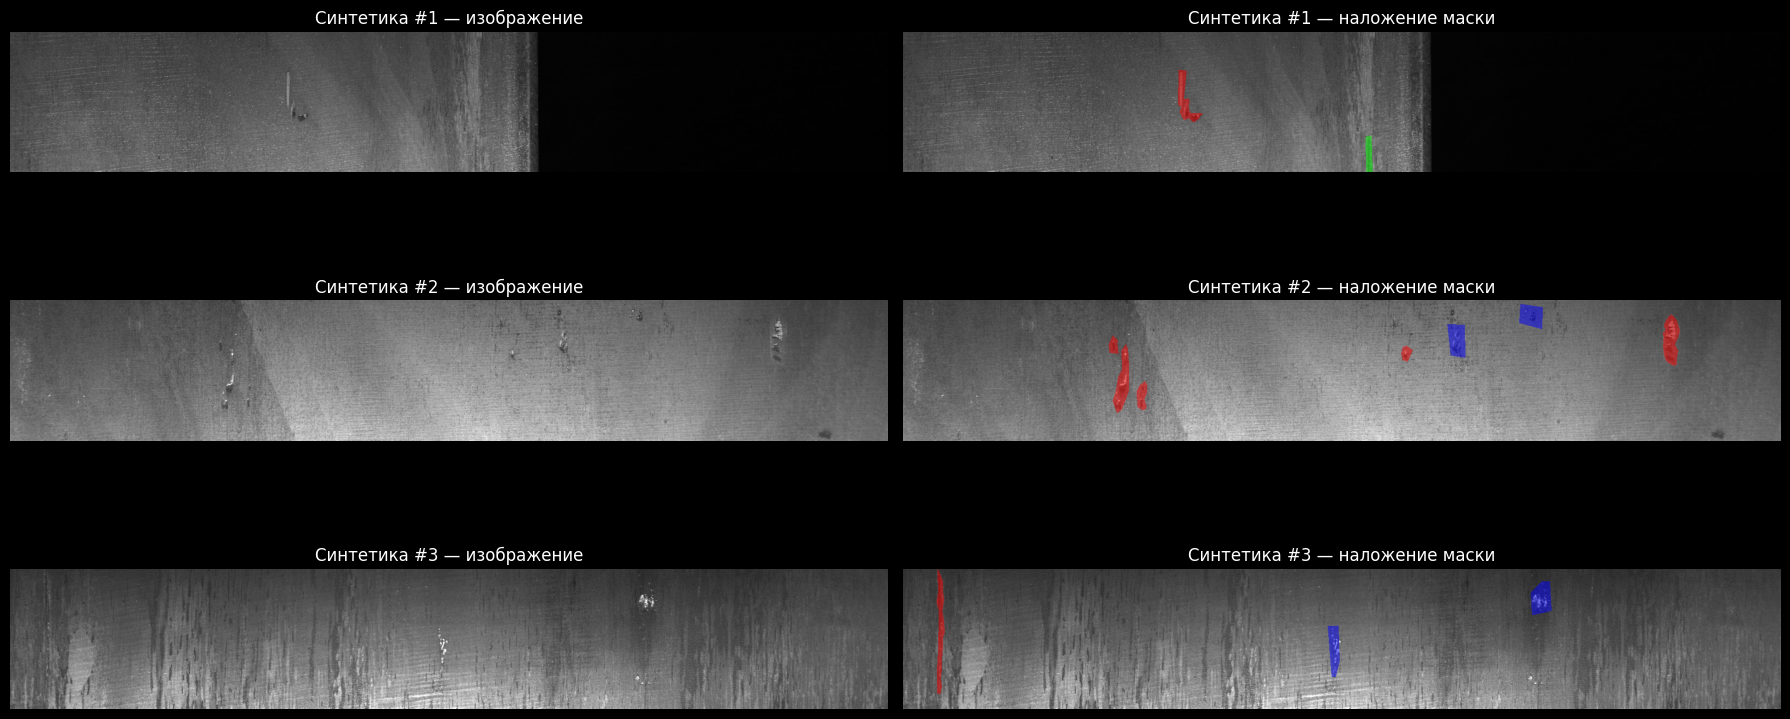

In [8]:
synth_cache = os.path.join(save_dir, 'synth_pairs_exp13.pkl')

if os.path.exists(synth_cache):
    print('Загружаем синтетику из кэша...')
    with open(synth_cache, 'rb') as f:
        synth_pairs = pickle.load(f)
    print(f'Загружено: {len(synth_pairs)} изображений')
else:
    # Цель — столько же пикселей класса 1+2, сколько класса 3 в обучающей выборке
    print('Подсчёт пикселей класса 3 в отобранных изображениях...')
    px_cls3 = sum(
        int((build_segmask(i, train_df) == 3).sum())
        for i in tqdm(selected_ids, desc='px_cls3')
    )
    print(f'Пикселей класса 3 в {len(selected_ids)} примерах: {px_cls3:,}')
    print(f'Цель синтетики (классы 1+2): ~{px_cls3:,} пикс.\n')

    synth_pairs = generate_synthetic(
        selected_ids=selected_ids,
        all_ids=labeled_ids,
        df=train_df,
        img_dir=TRAIN_IMG_DIR,
        classes_cache=classes_cache,
        target_pixels=px_cls3,
        cls_list=[1, 2],
    )
    with open(synth_cache, 'wb') as f:
        pickle.dump(synth_pairs, f)
    print(f'\nСинтетика сохранена: {synth_cache}')

print(f'\nИтого: {len(selected_ids)} реальных + {len(synth_pairs)} синтетических '
      f'= {len(selected_ids) + len(synth_pairs)} изображений')

# Визуализация нескольких примеров
colors = np.array([[0,0,0],[255,0,0],[0,255,0],[0,0,255],[255,255,0]], dtype=np.uint8)
n_show = min(3, len(synth_pairs))
fig, axes = plt.subplots(n_show, 2, figsize=(18, 3*n_show))
if n_show == 1: axes = axes[np.newaxis, :]
for i in range(n_show):
    img_arr, msk = synth_pairs[i]
    overlay = img_arr.copy()
    for c in range(1, NUM_CLASSES):
        overlay[msk == c] = (overlay[msk == c] * 0.5 + colors[c] * 0.5).astype(np.uint8)
    axes[i, 0].imshow(img_arr); axes[i, 0].set_title(f'Синтетика #{i+1} — изображение')
    axes[i, 1].imshow(overlay); axes[i, 1].set_title(f'Синтетика #{i+1} — наложение маски')
    for ax in axes[i]: ax.axis('off')
plt.tight_layout(); plt.show()

## 7. Архитектура: SegHeadDPT

In [9]:
class SegHeadDPT(nn.Module):
    """
    Декодер DPT-style.
    Вход:  список из 4 патч-токенов [B, PATCH_H*PATCH_W, EMBED_DIM] от слоёв 3,5,8,11
    Выход: карта сегментации [B, NUM_CLASSES, MASK_H, MASK_W]
    """
    def __init__(self, embed_dim=EMBED_DIM, num_classes=NUM_CLASSES,
                 patch_h=PATCH_H, patch_w=PATCH_W, n_layers=4):
        super().__init__()
        self.patch_h  = patch_h
        self.patch_w  = patch_w
        self.n_layers = n_layers

        self.proj = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(embed_dim, 256, 1),
                nn.BatchNorm2d(256), nn.GELU(),
            ) for _ in range(n_layers)
        ])
        self.fuse = nn.Sequential(
            nn.Conv2d(256 * n_layers, 512, 1),
            nn.BatchNorm2d(512), nn.GELU(),
            nn.Conv2d(512, 256, 3, padding=1),
            nn.BatchNorm2d(256), nn.GELU(),
        )
        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),
            nn.BatchNorm2d(128), nn.GELU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.GELU(),
        )
        self.up2 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.BatchNorm2d(64), nn.GELU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.GELU(),
        )
        self.head = nn.Conv2d(64, num_classes, 1)

    def forward(self, features):
        maps = []
        for i, f in enumerate(features):
            B, N, C = f.shape
            x = f.reshape(B, self.patch_h, self.patch_w, C).permute(0, 3, 1, 2)
            maps.append(self.proj[i](x))
        x = torch.cat(maps, dim=1)
        x = self.fuse(x)
        x = self.up1(x)
        x = self.up2(x)
        return self.head(x)


class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__(); self.s = smooth

    def forward(self, logits, targets):
        p       = F.softmax(logits, dim=1)
        B,C,H,W = p.shape
        t       = F.one_hot(targets, C).permute(0, 3, 1, 2).float()
        inter   = (p * t).sum(dim=(2, 3))
        union   = p.sum(dim=(2, 3)) + t.sum(dim=(2, 3))
        return 1 - ((2*inter + self.s) / (union + self.s)).mean()


_h = SegHeadDPT().to(DEVICE)
n_params = sum(p.numel() for p in _h.parameters())
with torch.no_grad():
    _d = [torch.randn(2, PATCH_H*PATCH_W, EMBED_DIM).to(DEVICE) for _ in range(4)]
    _o = _h(_d)
print(f'SegHeadDPT: {n_params:,} параметров')
print(f'Выход: {tuple(_o.shape)}  (ожидалось: (2, {NUM_CLASSES}, {MASK_H}, {MASK_W}))')
assert _o.shape == (2, NUM_CLASSES, MASK_H, MASK_W)
print('OK')
del _h, _d, _o

SegHeadDPT: 2,845,381 параметров
Выход: (2, 5, 64, 400)  (ожидалось: (2, 5, 64, 400))
OK


## 8. Функция обучения

In [10]:
def train_finetune(train_ids, val_ids, df, synth_pairs=None,
                   n_epochs=EPOCHS, label='exp13',
                   checkpoint_every=25):

    head = SegHeadDPT().to(DEVICE)

    backbone_params = [p for p in dinov2.parameters() if p.requires_grad]
    head_params     = list(head.parameters())
    opt = optim.AdamW([
        {'params': backbone_params, 'lr': LR_BACKBONE, 'weight_decay': 1e-2},
        {'params': head_params,     'lr': LR_HEAD,     'weight_decay': 1e-4},
    ])
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

    cw    = compute_class_weights(train_ids, df)
    cce   = nn.CrossEntropyLoss(weight=cw, reduction='none')
    cdice = DiceLoss()

    if synth_pairs is not None:
        tds = SteelSegDatasetWithSynth(
            train_ids, TRAIN_IMG_DIR, df, train_jt, synth_pairs)
    else:
        tds = SteelSegDataset(train_ids, TRAIN_IMG_DIR, df, train_jt)

    vds = SteelSegDataset(val_ids, TRAIN_IMG_DIR, df, val_jt)
    tdl = DataLoader(tds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    vdl = DataLoader(vds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    iou  = JaccardIndex(task='multiclass', num_classes=NUM_CLASSES,
                        average='none').to(DEVICE)
    hist = {'train_loss': [], 'val_miou': [], 'val_iou_per_class': []}
    best = 0.0
    best_state_head = None
    best_state_bb   = None

    n_bb = sum(p.numel() for p in backbone_params)
    n_hd = sum(p.numel() for p in head_params)
    print(f'Обучаемых параметров: backbone {n_bb/1e6:.1f}М + head {n_hd/1e3:.0f}К')
    print(f'Обучающих: {len(tds)}  |  Валидационных: {len(vds)}')
    if synth_pairs:
        print(f'  из них реальных: {len(train_ids)}, синтетических: {len(synth_pairs)}')
    print(f'Батчей на эпоху: {len(tdl)}')

    for ep in range(1, n_epochs + 1):
        dinov2.eval()
        for i, block in enumerate(dinov2.blocks):
            if i >= (n_blocks - N_UNFREEZE):
                block.train()
        dinov2.norm.train()
        head.train()

        tl = 0.0
        for imgs, masks, is_synth in tdl:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            feats = dinov2.get_intermediate_layers(
                imgs, n=INTERMEDIATE_LAYERS, return_class_token=False)
            lg = head(feats)

            # Синтетика получает пониженный вес SYNTH_WEIGHT
            pixel_loss = cce(lg, masks)                         # [B, H, W]
            w_batch    = torch.where(
                is_synth.bool().to(DEVICE)[:, None, None],
                torch.full_like(pixel_loss, SYNTH_WEIGHT),
                torch.ones_like(pixel_loss)
            )
            loss = (pixel_loss * w_batch).mean() + 0.5 * cdice(lg, masks)

            opt.zero_grad(); loss.backward(); opt.step()
            tl += loss.item()
        sched.step()

        dinov2.eval(); head.eval(); iou.reset()
        with torch.no_grad():
            for imgs, masks, _ in vdl:
                imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
                feats = dinov2.get_intermediate_layers(
                    imgs, n=INTERMEDIATE_LAYERS, return_class_token=False)
                iou.update(head(feats).argmax(1), masks)

        ipc = iou.compute().cpu().numpy()
        mi  = float(ipc.mean())
        hist['train_loss'].append(tl / len(tdl))
        hist['val_miou'].append(mi)
        hist['val_iou_per_class'].append(ipc.tolist())

        if mi > best:
            best = mi
            best_state_head = {k: v.clone() for k, v in head.state_dict().items()}
            best_state_bb   = {k: v.clone() for k, v in dinov2.state_dict().items()}

        if ep % 10 == 0 or ep == 1:
            s = '  '.join([f'cls{i}:{v:.3f}' for i, v in enumerate(ipc)])
            print(f'[{label}] Эп {ep:3d}/{n_epochs} | '
                  f'Loss:{tl/len(tdl):.4f} | mIoU:{mi:.4f} | {s}')

        if ep % checkpoint_every == 0:
            ckpt_path = os.path.join(save_dir, f'ckpt_{label}_ep{ep}.pt')
            torch.save({'epoch': ep,
                        'head_state': head.state_dict(),
                        'backbone_state': dinov2.state_dict(),
                        'history': hist,
                        'best_miou': best,
                        'n_train': len(tds)}, ckpt_path)
            print(f'  Чекпоинт: {ckpt_path}')

    head.load_state_dict(best_state_head)
    dinov2.load_state_dict(best_state_bb)
    print(f'\n  -> Лучший mIoU: {best:.4f}')
    return head, hist


print('Функция обучения определена.')

Функция обучения определена.


## 9. Обучение

In [11]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    free, total_mem = torch.cuda.mem_get_info()
    print(f'VRAM занято:   {torch.cuda.memory_allocated()/1e9:.1f} Гб')
    print(f'VRAM свободно: {free/1e9:.1f} Гб  /  {total_mem/1e9:.1f} Гб всего')

n_synth = len(synth_pairs)
print('='*75)
print(f'ЭКСП.13: {len(selected_ids)} реал. ({N_PER_CLASS}/класс) + {n_synth} синт., '
      f'{IMG_H}x{IMG_W}, backbone разморожен ({N_UNFREEZE} блоков)')
print('='*75)

model_13, history_13 = train_finetune(
    selected_ids, test_ids, train_df,
    synth_pairs=synth_pairs,
    label='exp13'
)

VRAM занято:   0.4 Гб
VRAM свободно: 6.9 Гб  /  8.5 Гб всего
ЭКСП.13: 778 реал. (200/класс) + 2268 синт., 224x1400, backbone разморожен (4 блоков)
Веса классов:
  Фон: 0.100  (301,878,692 пикс.)
  Дефект 1: 1.946  (882,239 пикс.)
  Дефект 2: 2.597  (661,191 пикс.)
  Дефект 3: 0.214  (8,021,328 пикс.)
  Дефект 4: 0.238  (7,225,350 пикс.)
Обучаемых параметров: backbone 28.4М + head 2845К
Обучающих: 3046  |  Валидационных: 1334
  из них реальных: 778, синтетических: 2268
Батчей на эпоху: 1523
[exp13] Эп   1/75 | Loss:0.2737 | mIoU:0.3247 | cls0:0.939  cls1:0.103  cls2:0.144  cls3:0.438  cls4:0.000
[exp13] Эп  10/75 | Loss:0.1061 | mIoU:0.5512 | cls0:0.967  cls1:0.344  cls2:0.264  cls3:0.590  cls4:0.591
[exp13] Эп  20/75 | Loss:0.0779 | mIoU:0.5359 | cls0:0.968  cls1:0.255  cls2:0.287  cls3:0.601  cls4:0.569
  Чекпоинт: C:/Users/ADMIN/Desktop/magistr/VKR/dino_heads\ckpt_exp13_ep25.pt
[exp13] Эп  30/75 | Loss:0.0658 | mIoU:0.5989 | cls0:0.971  cls1:0.379  cls2:0.365  cls3:0.622  cls4:0.657


## 10. Сравнение с предыдущими экспериментами

СРАВНЕНИЕ КОМПОНЕНТОВ:
Компонент                          Эксп.9      Эксп.10          Эксп.12             Эксп.13        
-------------------------------------------------------------------------------------------------
Backbone разморожен (бл.8-11)        да           да               да                  да          
DPT декодер                          да           да               да                  да          
JointTransform (flip+crop)           да           да               да                  да          
Синтетика copy-paste (кл.1+2)       нет          433              433                 2268         
Реальных изображений                200          200              200            778 (200/кл.)     
Всего обучающих                     200          633              633                 3046         

ИТОГОВОЕ СРАВНЕНИЕ (сортировка по mIoU):
  Эксперимент                                             mIoU
  -------------------------------------------------------------
  Эксп.5  

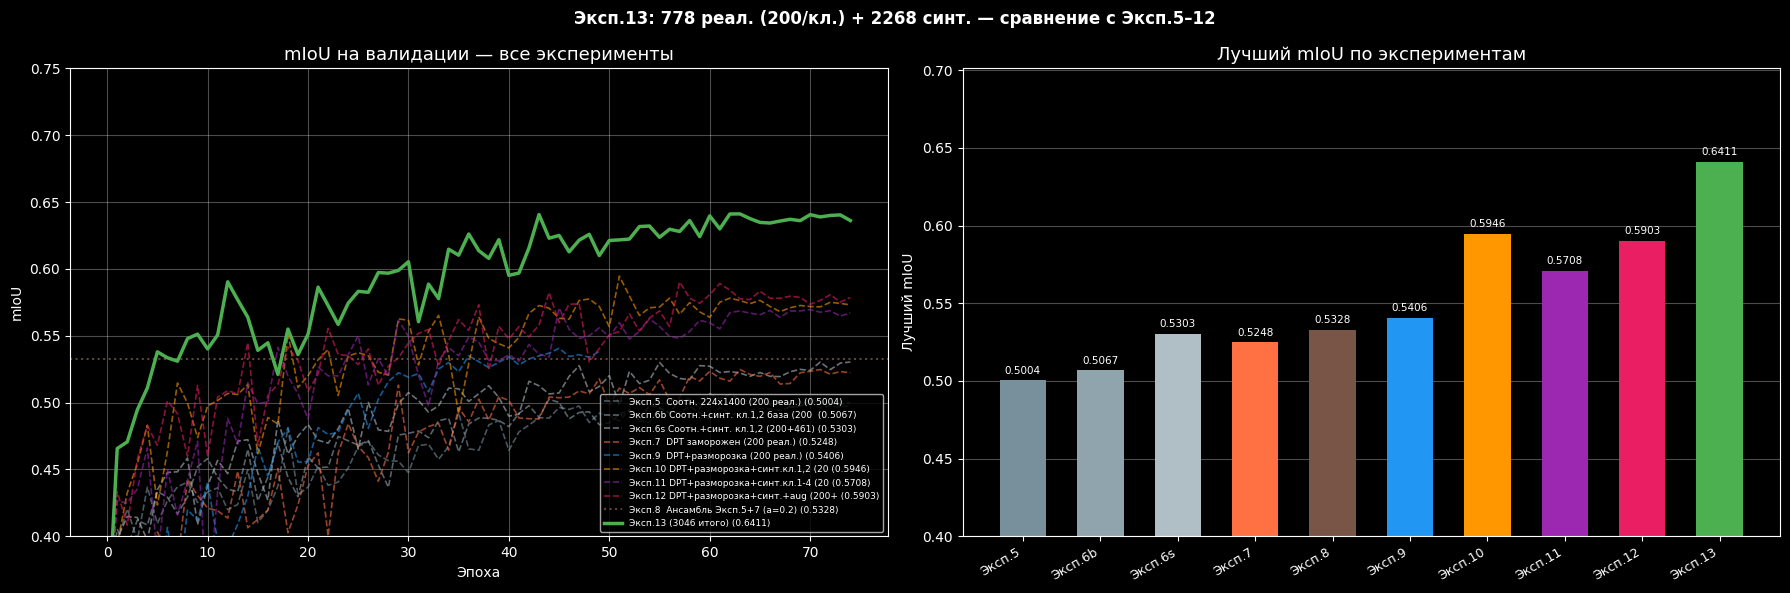

In [12]:
names = ['Фон', 'Дефект 1', 'Дефект 2', 'Дефект 3', 'Дефект 4']

m_13 = max(history_13['val_miou'])
e_13 = int(np.argmax(history_13['val_miou']))
i_13 = history_13['val_iou_per_class'][e_13]

# ── Таблица компонентов ────────────────────────────────────────────────
n_synth_13 = len(synth_pairs)
n_total_13 = len(selected_ids) + n_synth_13

print('СРАВНЕНИЕ КОМПОНЕНТОВ:')
print(f'{"Компонент":<33} {"Эксп.9":^8} {"Эксп.10":^16} {"Эксп.12":^16} {"Эксп.13":^22}')
print('-' * 97)
component_rows = [
    ('Backbone разморожен (бл.8-11)',  'да',  'да',  'да',  'да'),
    ('DPT декодер',                    'да',  'да',  'да',  'да'),
    ('JointTransform (flip+crop)',     'да',  'да',  'да',  'да'),
    ('Синтетика copy-paste (кл.1+2)', 'нет', '433', '433', str(n_synth_13)),
    ('Реальных изображений',           '200', '200', '200', f'{len(selected_ids)} (200/кл.)'),
    ('Всего обучающих',                '200', '633', '633', str(n_total_13)),
]
for row in component_rows:
    print(f'{row[0]:<33} {row[1]:^8} {row[2]:^16} {row[3]:^16} {row[4]:^22}')

# ── Стандартный формат: Эксп.5–7, 9–12 ────────────────────────────────
standard_cfgs = [
    ('Эксп.5  Соотн. 224x1400 (200 реал.)',          'history_ar_v2.json'),
    ('Эксп.6b Соотн.+синт. кл.1,2 база (200 реал.)', 'history_base6_v2.json'),
    ('Эксп.6s Соотн.+синт. кл.1,2 (200+461)',        'history_syn6_v2.json'),
    ('Эксп.7  DPT заморожен (200 реал.)',             'history_dpt_v2.json'),
    ('Эксп.9  DPT+разморозка (200 реал.)',            'history_ft_dpt_v2.json'),
    ('Эксп.10 DPT+разморозка+синт.кл.1,2 (200+433)', 'history_ft_dpt_synth_v2.json'),
    ('Эксп.11 DPT+разморозка+синт.кл.1-4 (200+131)', 'history_ft_dpt_synth_all_v2.json'),
    ('Эксп.12 DPT+разморозка+синт.+aug (200+433)',    'history_ft_dpt_aug.json'),
]

results = {}
for name, fname in standard_cfgs:
    p = os.path.join(save_dir, fname)
    if os.path.exists(p):
        with open(p) as f: h = json.load(f)
        m = max(h['val_miou']); e = int(np.argmax(h['val_miou']))
        results[name] = {'miou': m, 'iou': h['val_iou_per_class'][e],
                         'hist': h, 'has_curve': True}
    else:
        print(f'[!] Не найден: {fname}')

# Эксп.8 — особый формат
ens_path = os.path.join(save_dir, 'history_ensemble_v2.json')
if os.path.exists(ens_path):
    with open(ens_path) as f: h8 = json.load(f)
    results['Эксп.8  Ансамбль Эксп.5+7 (a=0.2)'] = {
        'miou': h8['miou_ensemble_best'], 'iou': h8['iou_ensemble_best'],
        'hist': h8, 'has_curve': False}

# Текущий эксп.13
exp13_label = (f'Эксп.13 DPT+разморозка+синт. '
               f'({len(selected_ids)} реал.+{n_synth_13} синт.)')
all_results = dict(results)
all_results[exp13_label] = {
    'miou': m_13, 'iou': i_13, 'hist': history_13, 'has_curve': True}

# ── Итоговая таблица mIoU ──────────────────────────────────────────────
print('\nИТОГОВОЕ СРАВНЕНИЕ (сортировка по mIoU):')
print(f'  {"Эксперимент":<52} {"mIoU":>7}')
print('  ' + '-'*61)
best_name = max(all_results, key=lambda k: all_results[k]['miou'])
for name, r in sorted(all_results.items(), key=lambda x: x[1]['miou']):
    marker = ' <- лучший' if name == best_name else ''
    print(f'  {name:<52} {r["miou"]:>7.4f}{marker}')

best_prev = max(results.values(), key=lambda r: r['miou'])
delta = (m_13 - best_prev['miou']) * 100
best_prev_name = max(results, key=lambda k: results[k]['miou'])
print(f'\n  Прирост Эксп.13 vs лучшего ({best_prev_name.split()[0]}): {delta:+.1f}%')

# ── IoU по классам (ключевые эксперименты) ─────────────────────────────
key_exps = ['Эксп.9  DPT+разморозка (200 реал.)',
            'Эксп.10 DPT+разморозка+синт.кл.1,2 (200+433)',
            'Эксп.12 DPT+разморозка+синт.+aug (200+433)',
            exp13_label]
shown = {k: all_results[k] for k in key_exps if k in all_results}
short = [k.split()[0] for k in shown]

print(f'\n  {"Класс":<14}' + ''.join(f'{n:>10}' for n in short))
print('  ' + '-'*(14 + 10*len(shown)))
for c in range(NUM_CLASSES):
    print(f'  {names[c]:<14}' + ''.join(f'{r["iou"][c]:>10.4f}' for r in shown.values()))

# ── Графики ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

palette = ['#78909C','#90A4AE','#B0BEC5','#FF7043','#2196F3','#FF9800','#9C27B0','#E91E63']
curve_items = [(n, r) for n, r in results.items() if r['has_curve']]
ens_items   = [(n, r) for n, r in results.items() if not r['has_curve']]

for (name, r), col in zip(curve_items, palette):
    axes[0].plot(r['hist']['val_miou'], color=col, lw=1.2, alpha=0.6,
                 ls='--', label=f'{name[:38]} ({r["miou"]:.4f})')
for (name, r), col in zip(ens_items, ['#795548']):
    axes[0].axhline(r['miou'], color=col, lw=1.5, ls=':', alpha=0.8,
                    label=f'{name[:38]} ({r["miou"]:.4f})')
axes[0].plot(history_13['val_miou'], color='#4CAF50', lw=2.5,
             label=f'Эксп.13 ({n_total_13} итого) ({m_13:.4f})')
axes[0].set_title('mIoU на валидации — все эксперименты', fontsize=13)
axes[0].set_xlabel('Эпоха'); axes[0].set_ylabel('mIoU')
axes[0].legend(fontsize=6.5, loc='lower right'); axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0.40, 0.75)

# Bar chart
ordered = [
    'Эксп.5  Соотн. 224x1400 (200 реал.)',
    'Эксп.6b Соотн.+синт. кл.1,2 база (200 реал.)',
    'Эксп.6s Соотн.+синт. кл.1,2 (200+461)',
    'Эксп.7  DPT заморожен (200 реал.)',
    'Эксп.8  Ансамбль Эксп.5+7 (a=0.2)',
    'Эксп.9  DPT+разморозка (200 реал.)',
    'Эксп.10 DPT+разморозка+синт.кл.1,2 (200+433)',
    'Эксп.11 DPT+разморозка+синт.кл.1-4 (200+131)',
    'Эксп.12 DPT+разморозка+синт.+aug (200+433)',
    exp13_label,
]
bar_palette = ['#78909C','#90A4AE','#B0BEC5','#FF7043','#795548',
               '#2196F3','#FF9800','#9C27B0','#E91E63','#4CAF50']
bar_names, bar_vals, bar_cols = [], [], []
for name, col in zip(ordered, bar_palette):
    if name in all_results:
        bar_names.append(name.split()[0])
        bar_vals.append(all_results[name]['miou'])
        bar_cols.append('#4CAF50' if name == exp13_label else col)

bars = axes[1].bar(range(len(bar_vals)), bar_vals, color=bar_cols, width=0.6, zorder=2)
axes[1].set_xticks(range(len(bar_names)))
axes[1].set_xticklabels(bar_names, rotation=30, ha='right', fontsize=9)
axes[1].set_ylabel('Лучший mIoU'); axes[1].set_title('Лучший mIoU по экспериментам', fontsize=13)
axes[1].set_ylim(0.40, max(bar_vals) + 0.06); axes[1].grid(True, axis='y', alpha=0.3, zorder=1)
for bar, val in zip(bars, bar_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=7.5)

plt.suptitle(
    f'Эксп.13: {len(selected_ids)} реал. (200/кл.) + {n_synth_13} синт. — сравнение с Эксп.5–12',
    fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


## 11. Сохранение

In [13]:
torch.save(model_13.state_dict(),
           os.path.join(save_dir, 'model_exp13.pt'))
torch.save(dinov2.state_dict(),
           os.path.join(save_dir, 'dinov2_exp13.pt'))
with open(os.path.join(save_dir, 'history_exp13.json'), 'w') as f:
    json.dump(history_13, f)

meta = {
    'n_per_class':       N_PER_CLASS,
    'n_real':            len(selected_ids),
    'n_synth':           len(synth_pairs),
    'n_total':           len(selected_ids) + len(synth_pairs),
    'selected_ids':      selected_ids,
    'per_class_ids':     {str(k): v for k, v in per_class.items()},
    'best_miou':         m_13,
    'best_epoch':        e_13 + 1,
    'best_iou_per_class': i_13,
}
with open(os.path.join(save_dir, 'exp13_meta.json'), 'w') as f:
    json.dump(meta, f, indent=2)

print('Сохранено:')
print('  model_exp13.pt       — голова DPT')
print('  dinov2_exp13.pt      — backbone после fine-tuning')
print('  history_exp13.json   — история обучения')
print('  exp13_meta.json      — отобранные изображения + метрики')
print(f'\nЛучший mIoU: {m_13:.4f}  (эпоха {e_13+1})')
print(f'IoU по классам: {[f"{v:.3f}" for v in i_13]}')

Сохранено:
  model_exp13.pt       — голова DPT
  dinov2_exp13.pt      — backbone после fine-tuning
  history_exp13.json   — история обучения
  exp13_meta.json      — отобранные изображения + метрики

Лучший mIoU: 0.6411  (эпоха 64)
IoU по классам: ['0.974', '0.476', '0.417', '0.655', '0.684']
